# 03 — Robustness of the LSM scalars under alternative transformations

Notebook 02 reported a single trial-band (age 65–80) mean and SD on the raw kPa scale. The project consumes those two scalars to fit a *lognormal* exposure distribution by moment-matching:

$$\mu = \log\!\left(\frac{m^2}{\sqrt{m^2 + s^2}}\right),\quad \sigma = \sqrt{\log\!\left(1 + \frac{s^2}{m^2}\right)}$$

For LSM, the **F4 share** (LSM ≥ 12.5 kPa) is the load-bearing quantity — it determines how many simulants get cirrhosis EMR vs MASLD EMR. So the goodness-of-fit criterion at the upper tail is even sharper here than for Lp(a).

This notebook mirrors `nhanes_lpa_distribution/03_lpa_transformations.ipynb`:

1. Distribution shape on raw / sqrt / log scales.
2. Mean and SD computed on transformed scales then back-transformed.
3. Outlier sensitivity (drop top 1 %, 5 %, 10 %).
4. Lognormal-from-scalars goodness-of-fit at the upper tail (P90 / P95 / P99) **and** the F4 share.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'
df = pd.read_parquet(DERIVED_DIR / 'nhanes_p_lux.parquet')
ana = df[df['exam_complete'] & df['LSM_KPA'].notna() & df['WTMECPRP'].fillna(0).gt(0)].copy()
trial = ana[(ana['age_years'] >= 65) & (ana['age_years'] <= 80)].copy()
print(f'trial-band 65-80 n = {len(trial):,}')

F4_CUTOFF = 12.5
PROJECT_MEAN = 6.0
PROJECT_SD = 4.0

def w_mean(y, w): return float(np.average(y, weights=w))
def w_var(y, w):  m = w_mean(y, w); return float(np.average((y - m) ** 2, weights=w))
def w_sd(y, w):   return float(np.sqrt(w_var(y, w)))
def w_quantile(y, w, q):
    o = np.argsort(y); ys, ws = y[o], w[o]
    cw = np.cumsum(ws) / ws.sum()
    return float(np.interp(q, cw, ys))

y = trial['LSM_KPA'].values.astype(float)
w = trial['WTMECPRP'].values.astype(float)

# LSM detection floor is ~1.5 kPa (FibroScan), so log(y) is always
# defined; no offset needed.
OFFSET = 0.0

trial-band 65-80 n = 1,787


## 1. Distribution on raw / sqrt / log scales

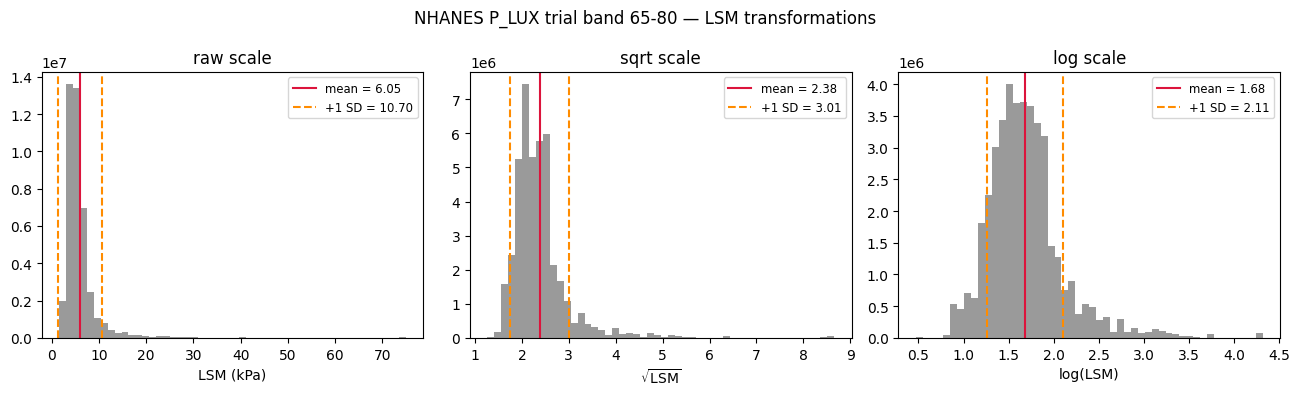

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
scales = [
    ('raw',  y,                'LSM (kPa)'),
    ('sqrt', np.sqrt(y),       r'$\sqrt{\mathrm{LSM}}$'),
    ('log',  np.log(y),        'log(LSM)'),
]
for ax, (label, vals, xlab) in zip(axes, scales):
    ax.hist(vals, bins=50, weights=w, color='#888', alpha=0.85)
    m = w_mean(vals, w); s = w_sd(vals, w)
    ax.axvline(m, color='crimson', label=f'mean = {m:.2f}')
    ax.axvline(m + s, color='darkorange', linestyle='--', label=f'+1 SD = {m+s:.2f}')
    ax.axvline(m - s, color='darkorange', linestyle='--')
    ax.set_xlabel(xlab)
    ax.set_title(f'{label} scale')
    ax.legend(fontsize='small')
fig.suptitle('NHANES P_LUX trial band 65-80 — LSM transformations')
fig.tight_layout()
plt.show()

## 2. Back-transformed central estimates

In [3]:
rows = []
rows.append({'scale': 'raw',  'mean': w_mean(y, w),         'SD': w_sd(y, w),
             'back_mean': w_mean(y, w),                      'back_SD': w_sd(y, w)})
ms = w_mean(np.sqrt(y), w); ss = w_sd(np.sqrt(y), w)
rows.append({'scale': 'sqrt', 'mean': ms, 'SD': ss,
             'back_mean': ms ** 2 + ss ** 2,
             'back_SD':   np.sqrt(4 * ms ** 2 * ss ** 2)})
mu_log = w_mean(np.log(y), w); sigma_log = w_sd(np.log(y), w)
back_m = np.exp(mu_log + sigma_log ** 2 / 2.0)
back_s = back_m * np.sqrt(np.exp(sigma_log ** 2) - 1.0)
rows.append({'scale': 'log',  'mean': mu_log, 'SD': sigma_log,
             'back_mean': back_m, 'back_SD': back_s})
tab = pd.DataFrame(rows).round(3)
print(tab.to_string(index=False))

scale  mean    SD  back_mean  back_SD
  raw 6.053 4.648      6.053    4.648
 sqrt 2.379 0.627      6.053    2.984
  log 1.683 0.423      5.884    2.601


## 3. Outlier sensitivity

In [4]:
rows = []
for top_pct in [0, 1, 5, 10]:
    if top_pct == 0:
        sy, sw = y, w
    else:
        cut = w_quantile(y, w, 1.0 - top_pct / 100.0)
        sy = y[y <= cut]
        sw = w[y <= cut]
    rows.append({
        'top % trimmed': top_pct,
        'cutoff (kPa)':  w_quantile(y, w, 1.0 - top_pct / 100.0) if top_pct > 0 else float('inf'),
        'n':             len(sy),
        'mean (kPa)':    w_mean(sy, sw),
        'SD (kPa)':      w_sd(sy, sw),
    })
tab_trim = pd.DataFrame(rows).round(3)
print(tab_trim.to_string(index=False))

 top % trimmed  cutoff (kPa)    n  mean (kPa)  SD (kPa)
             0           inf 1787       6.053     4.648
             1        23.292 1764       5.707     2.706
             5        11.597 1687       5.289     1.696
            10         8.686 1580       5.035     1.335


## 4. Lognormal goodness-of-fit + F4 share

For LSM the F4 share (P > F4 cutoff) is the threshold-EMR routing input. Compare:

- moment-matched lognormal **from project stub (6, 4)** — what the simulation actually does today,
- moment-matched lognormal **from NHANES trial-band scalars** — the proposed update,
- empirical NHANES — the truth we're trying to match.

Anything off by more than ~30 % in the F4 share is a calibration issue.

In [5]:
def moment_match_lognormal(m, s):
    sigma2 = np.log(1 + (s / m) ** 2)
    mu = np.log(m ** 2 / np.sqrt(m ** 2 + s ** 2))
    return mu, np.sqrt(sigma2)

trial_mean = w_mean(y, w); trial_sd = w_sd(y, w)
mu_proj, sigma_proj = moment_match_lognormal(PROJECT_MEAN, PROJECT_SD)
mu_nhanes, sigma_nhanes = moment_match_lognormal(trial_mean, trial_sd)

qs = [0.50, 0.75, 0.90, 0.95, 0.99]
rows = []
for q in qs:
    rows.append({
        'quantile':                       q,
        'empirical (kPa)':                w_quantile(y, w, q),
        'lognormal (project 6,4) (kPa)':  float(np.exp(stats.norm.ppf(q) * sigma_proj + mu_proj)),
        'lognormal (NHANES) (kPa)':       float(np.exp(stats.norm.ppf(q) * sigma_nhanes + mu_nhanes)),
    })
tab_q = pd.DataFrame(rows).round(2)
print(tab_q.to_string(index=False))
print()

# Implied F4 share (P > 12.5) under each lognormal.
p_f4_proj   = 1 - stats.norm.cdf((np.log(F4_CUTOFF) - mu_proj) / sigma_proj)
p_f4_nhanes = 1 - stats.norm.cdf((np.log(F4_CUTOFF) - mu_nhanes) / sigma_nhanes)
p_f4_emp    = float(np.average((y >= F4_CUTOFF).astype(float), weights=w))
print(f'F4 share (P[LSM ≥ {F4_CUTOFF} kPa]):')
print(f'  project stub lognormal (6, 4):     {100*p_f4_proj:.1f} %')
print(f'  NHANES-scalar lognormal:           {100*p_f4_nhanes:.1f} %')
print(f'  empirical (NHANES trial band):     {100*p_f4_emp:.1f} %')

 quantile  empirical (kPa)  lognormal (project 6,4) (kPa)  lognormal (NHANES) (kPa)
     0.50             5.10                           4.99                      4.80
     0.75             6.40                           7.52                      7.60
     0.90             8.69                          10.86                     11.49
     0.95            11.60                          13.54                     14.71
     0.99            23.29                          20.46                     23.40

F4 share (P[LSM ≥ 12.5 kPa]):
  project stub lognormal (6, 4):     6.5 %
  NHANES-scalar lognormal:           8.0 %
  empirical (NHANES trial band):     4.1 %


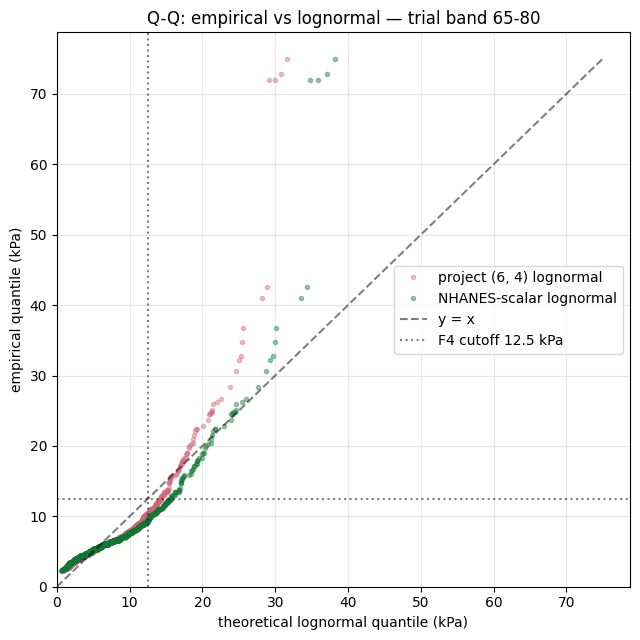

In [6]:
order = np.argsort(y)
y_s, w_s = y[order], w[order]
cw = np.cumsum(w_s) / w_s.sum()
mask = (cw > 1e-3) & (cw < 1 - 1e-3)
th_proj   = np.exp(stats.norm.ppf(cw[mask]) * sigma_proj + mu_proj)
th_nhanes = np.exp(stats.norm.ppf(cw[mask]) * sigma_nhanes + mu_nhanes)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(th_proj,   y_s[mask], '.', alpha=0.4, color='#cc6677', label='project (6, 4) lognormal')
ax.plot(th_nhanes, y_s[mask], '.', alpha=0.4, color='#117733', label='NHANES-scalar lognormal')
lim = max(y_s.max(), th_proj.max(), th_nhanes.max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y = x')
ax.axvline(F4_CUTOFF, color='black', linestyle=':', alpha=0.5)
ax.axhline(F4_CUTOFF, color='black', linestyle=':', alpha=0.5,
           label=f'F4 cutoff {F4_CUTOFF} kPa')
ax.set_xlabel('theoretical lognormal quantile (kPa)')
ax.set_ylabel('empirical quantile (kPa)')
ax.set_title('Q-Q: empirical vs lognormal — trial band 65-80')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, lim * 1.05)
ax.set_ylim(0, lim * 1.05)
fig.tight_layout()
plt.show()

## 5. Decision

Same checks as for Lp(a), plus the LSM-specific F4-share check:

- **Section 2** — log-scale-implied mean within ~10 % of raw mean?
- **Section 3** — top-5 % trim moves the mean by < ~10 %?
- **Section 4 — central** — moment-matched lognormal upper-tail percentiles within ±20 % of empirical?
- **Section 4 — F4 share** — moment-matched lognormal F4 share within ±30 % of empirical?

If the project stub `(6, 4)` fails the F4-share check materially, we should switch to the trial-band NHANES scalars even though the simple-scalar form is approximate.

In [7]:
raw_mean = w_mean(y, w); raw_sd = w_sd(y, w)
log_back_mean = float(np.exp(mu_log + sigma_log ** 2 / 2.0))
cut95 = w_quantile(y, w, 0.95); trim_mean = w_mean(y[y <= cut95], w[y <= cut95])
log_p99_proj = float(np.exp(stats.norm.ppf(0.99) * sigma_proj + mu_proj))
log_p99_nh   = float(np.exp(stats.norm.ppf(0.99) * sigma_nhanes + mu_nhanes))
emp_p99      = w_quantile(y, w, 0.99)

print(f'NHANES trial-band raw mean:  {raw_mean:.2f} kPa  (SD = {raw_sd:.2f})')
print(f'log-scale-implied mean:      {log_back_mean:.2f}  (Δ {log_back_mean - raw_mean:+.2f})')
print(f'top-5 % trimmed mean:        {trim_mean:.2f}  (Δ {trim_mean - raw_mean:+.2f})')
print()
print(f'Empirical P99:                       {emp_p99:.1f} kPa')
print(f'Lognormal P99, project stub (6, 4):  {log_p99_proj:.1f}  (ratio {log_p99_proj/emp_p99:.2f})')
print(f'Lognormal P99, NHANES scalars:       {log_p99_nh:.1f}  (ratio {log_p99_nh/emp_p99:.2f})')
print()
print(f'F4 share check:')
print(f'  project stub (6, 4):  {100*p_f4_proj:.1f} %')
print(f'  NHANES scalars:       {100*p_f4_nhanes:.1f} %')
print(f'  empirical:            {100*p_f4_emp:.1f} %')
print(f'  proj/emp ratio:       {p_f4_proj/p_f4_emp:.2f}')
print(f'  NHANES/emp ratio:     {p_f4_nhanes/p_f4_emp:.2f}')

NHANES trial-band raw mean:  6.05 kPa  (SD = 4.65)
log-scale-implied mean:      5.88  (Δ -0.17)
top-5 % trimmed mean:        5.29  (Δ -0.76)

Empirical P99:                       23.3 kPa
Lognormal P99, project stub (6, 4):  20.5  (ratio 0.88)
Lognormal P99, NHANES scalars:       23.4  (ratio 1.00)

F4 share check:
  project stub (6, 4):  6.5 %
  NHANES scalars:       8.0 %
  empirical:            4.1 %
  proj/emp ratio:       1.57
  NHANES/emp ratio:     1.93
